Zadanie 10 -- GRU na szeregu czasowym
Wygeneruj syntetyczny szereg czasowy (sinusoida + trend + szum). Wytrenuj GRU do predykcji następnej
wartości. Zwizualizuj predykcje.
Wymagania:
- create_sequences() z oknem 30 kroków
- GRU32 + Dense(1)
- Wykres: rzeczywiste vs predykcje
- MSE, MAE

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Train: (1576, 30, 1), Test: (394, 30, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1182 - mae: 0.2730 - val_loss: 0.0247 - val_mae: 0.1297
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0318 - mae: 0.1363 - val_loss: 0.0241 - val_mae: 0.1290
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0285 - mae: 0.1295 - val_loss: 0.0215 - val_mae: 0.1226
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0284 - mae: 0.1287 - val_loss: 0.0257 - val_mae: 0.1328
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0272 - mae: 0.1267 - val_loss: 0.0236 - val_mae: 0.1277
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0272 - mae: 0.1231 - val_loss: 0.0156 - val_mae: 0.1040
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0210 - mae: 0.1026 - val_loss: 0.0242 - val_mae: 0.1387
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - mae: 0.0748 - val_loss: 0.0230 - val_mae: 0.1392
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0110 - mae: 

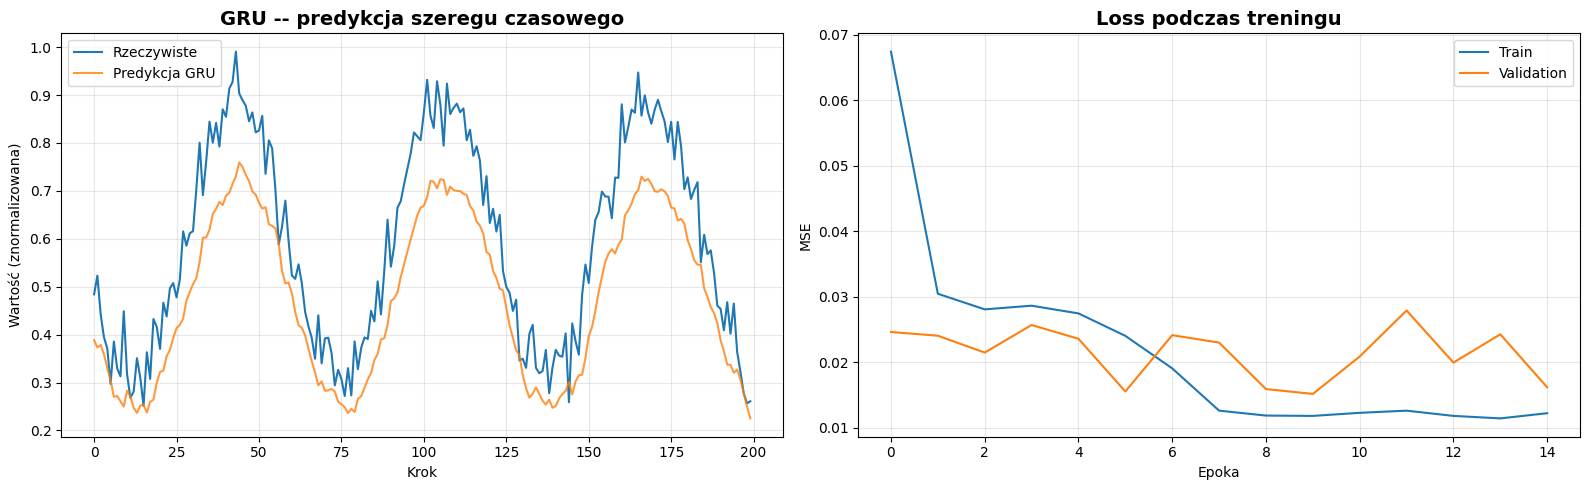

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generowanie syntetycznego szeregu: sinusoida + trend + szum
np.random.seed(42)
t = np.arange(0, 200, 0.1)
data = np.sin(t) * 10 + t * 0.05 + np.random.randn(len(t)) * 1.5

# Normalizacja do [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# Tworzenie sekwencji: X = [t-30, ..., t-1], y = t
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 30  # okno 30 kroków
X, y = create_sequences(data_scaled, seq_length)

# Reshape dla RNN: (samples, timesteps, features)
X = X.reshape(-1, seq_length, 1)

# Podział train/test (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Model: GRU(32) + Dense(1)
model = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.GRU(32, dropout=0.2),
    layers.Dense(1),  # regresja -- brak aktywacji
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1,
)

# Predykcja
y_pred = model.predict(X_test, verbose=0).flatten()

# Metryki
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

# Wizualizacja: rzeczywiste vs predykcje + loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test[:200], label="Rzeczywiste", linewidth=1.5)
axes[0].plot(y_pred[:200], label="Predykcja GRU", linewidth=1.5, alpha=0.8)
axes[0].set_title("GRU -- predykcja szeregu czasowego", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Krok")
axes[0].set_ylabel("Wartość (znormalizowana)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss podczas treningu", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
